In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_score

In [24]:
## Data Loading & Preparation
## We merge outreach campaign data with SDOH features to create a modeling dataset.
outreach = pd.read_csv('outreach_campaign.csv')
sdoh = pd.read_csv('sdoh_data.csv')

# Merge datasets
df = outreach.merge(sdoh, on='member_id')
df.head()

,campaign_id,member_id,outreach_type,language,response,renewal_completed,income_level,housing_status,employment_status,transportation_access,food_security
0,1,100000,Email,English,No,No,High,Unstable,Employed,Yes,Secure
1,2,100001,Email,English,Yes,Yes,Low,Stable,Employed,No,Secure
2,3,100002,SMS,Spanish,No,No,Medium,Stable,Unemployed,Yes,Secure
3,4,100003,Email,English,No,No,Medium,Stable,Unemployed,No,Secure
4,5,100004,SMS,English,Yes,Yes,Medium,Stable,Unemployed,No,Secure


In [21]:
## Target Variable
## We convert renewal_completed into a binary variable:
## - 1 = Renewed
## - 0 = Not Renewed

df['target'] = df['renewal_completed'].map({'Yes': 1, 'No': 0})

In [20]:
## Feature Engineering We encode categorical variables such as: - Outreach Type, Language, Income Level, Housing Status, Transportation Access

df_encoded = pd.get_dummies(df[[
    'outreach_type',
    'language',
    'income_level',
    'housing_status',
    'transportation_access'
]], drop_first=True)

In [19]:
## Train-Test Split We split the dataset into training and testing sets (80/20).
X = df_encoded
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
## Logistic Regression Model We use logistic regression to predict the probability of member renewal.
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [7]:
y_pred = model.predict(X_test)

In [8]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[6722    0]
 [3278    0]]


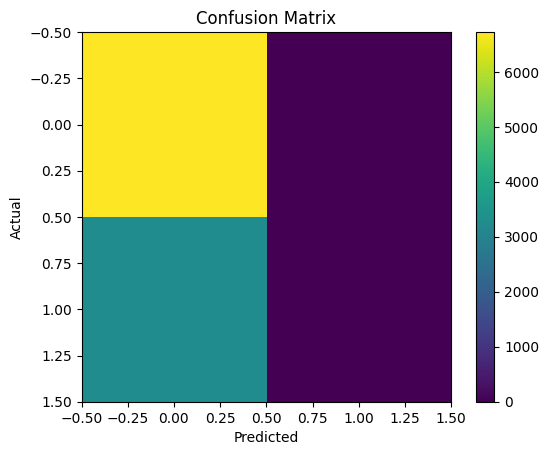

In [9]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [17]:
## Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80      6722
           1       0.00      0.00      0.00      3278

    accuracy                           0.67     10000
   macro avg       0.34      0.50      0.40     10000
weighted avg       0.45      0.67      0.54     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
## Feature Importance Understanding which factors influence renewal behavior.

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance

,Feature,Coefficient
0,outreach_type_SMS,0.990939
1,language_Spanish,0.021414
4,housing_status_Unstable,0.010243
5,transportation_access_Yes,-0.002723
3,income_level_Medium,-0.009222
2,income_level_Low,-0.011246
